In [1]:
# import matplotlib for data visualization
import matplotlib.pyplot as plt

# import pandas for data manipulation and analysis
import pandas as pd

# import numpy for numerical operations
import numpy as np

In [2]:
# read the placement dataset from the CSV file
df = pd.read_csv('placement.csv')

In [3]:
# display the first five rows of the dataset
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package(in lpa)')

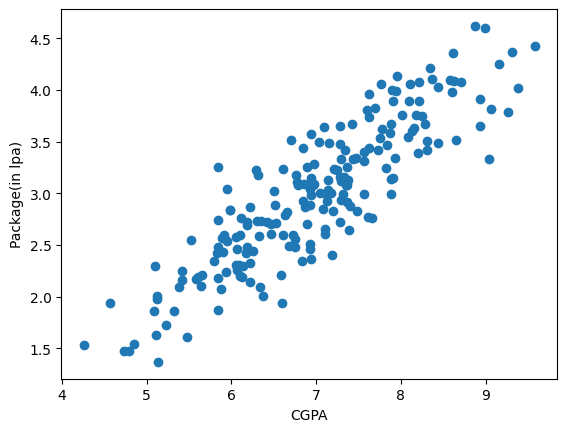

In [4]:
# create a scatter plot to visualize the relationship between CGPA and package
plt.scatter(df['cgpa'], df['package'])

# label the x-axis as CGPA
plt.xlabel('CGPA')

# label the y-axis as package in LPA
plt.ylabel('Package(in lpa)')

In [5]:
# select the first column as the input feature (CGPA)
X = df.iloc[:, 0:1]

# select the last column as the target variable (package)
y = df.iloc[:, -1]

In [6]:
# import the function to split the data into training and testing sets
from sklearn.model_selection import train_test_split

# split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

In [7]:
# import the linear regression model from scikit-learn
from sklearn.linear_model import LinearRegression

# create an object of the linear regression model
lr = LinearRegression()

# train the model using the training data
lr.fit(X_train, y_train)

LinearRegression()

Text(0, 0.5, 'Package(in lpa)')

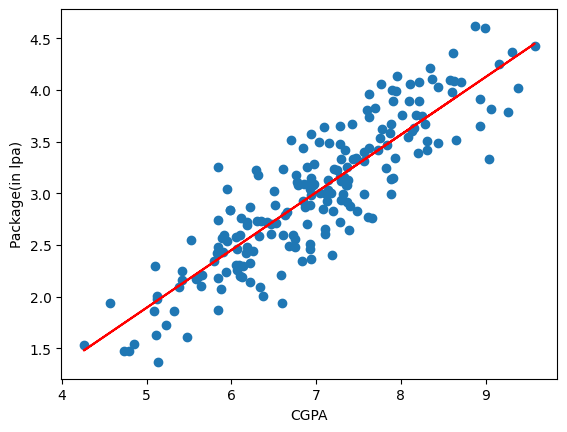

In [8]:
# create a scatter plot of CGPA and package
plt.scatter(df['cgpa'], df['package'])

# plot the linear regression line using the training data
plt.plot(X_train, lr.predict(X_train), color='red')

# label the x-axis as CGPA
plt.xlabel('CGPA')

# label the y-axis as package in LPA
plt.ylabel('Package(in lpa)')

In [9]:
# import evaluation metrics to measure the performance of the regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [10]:
# make predictions on the test data using the trained linear regression model
y_pred = lr.predict(X_test)

In [11]:
# calculate the mean absolute error between actual and predicted values
print("MAE: ", mean_absolute_error(y_test, y_pred))

# calculate the mean squared error between actual and predicted values
print("MSE:", mean_squared_error(y_test, y_pred))

# calculate the root mean squared error
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))

# calculate the R-squared score to measure how well the model explains the variation in the target
print("R2: ", r2_score(y_test, y_pred))

MAE:  0.2884710931878175
MSE: 0.12129235313495527
RMSE:  0.34827051717731616
R2:  0.780730147510384


### **Adjusted R2**

In [12]:
# calculate the R-squared score and store it in the variable r2
r2 = r2_score(y_test, y_pred)

In [13]:
# display the number of rows and columns in the test data
X_test.shape

(40, 1)

In [14]:
# calculate the adjusted R-squared value using the R-squared score
1 - ((1 - r2) * (40 - 1) / (40 - 1 - 1))

0.7749598882343415

### **Adding Irrelevant Feature**

In [15]:
# create a copy of the original dataset
new_df1 = df.copy()

# add a new column containing random values for each row
new_df1['random_feature'] = np.random.random(200)

# rearrange the columns to keep CGPA, random feature, and package
new_df1 = new_df1[['cgpa', 'random_feature', 'package']]

# display the first five rows of the modified dataset
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.193741,3.26
1,5.12,0.048901,1.98
2,7.82,0.164194,3.25
3,7.42,0.057443,3.67
4,6.94,0.094097,3.57


Text(0, 0.5, 'Package(in lpa)')

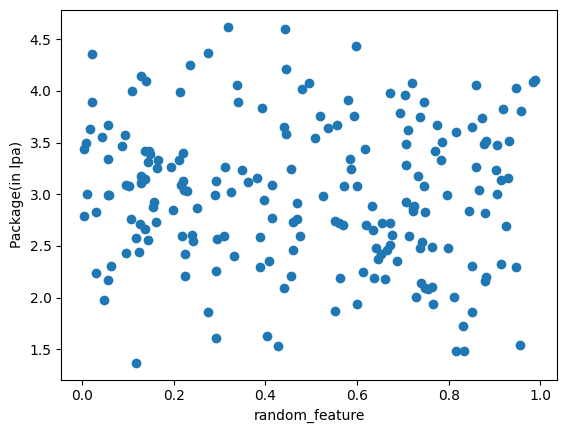

In [16]:
# create a scatter plot to check the relationship between the random feature and package
plt.scatter(new_df1['random_feature'], new_df1['package'])

# label the x-axis as random feature
plt.xlabel('random_feature')

# label the y-axis as package in LPA
plt.ylabel('Package(in lpa)')

In [17]:
# select CGPA and random feature as input variables
X = new_df1.iloc[:, 0:2]

# select package as the target variable
y = new_df1.iloc[:, -1]

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

# create a linear regression model
lr = LinearRegression()

# train the model using the training data
lr.fit(X_train, y_train)

# make predictions on the test data
y_pred = lr.predict(X_test)

In [18]:
# calculate the R-squared score for the model
print("R2 score: ", r2_score(y_test, y_pred))

# store the R-squared score in the variable r2
r2 = r2_score(y_test, y_pred)

R2 score:  0.7806175531246902


In [19]:
# calculate the adjusted R-squared value for the model with 2 input features
1 - ((1 - r2) * (40 - 1) / (40 - 1 - 2))

0.7687590424827815

### **Adding Relevant Feature**

In [20]:
# create a copy of the original dataset
new_df2 = df.copy()

# create a new IQ feature by adding random noise to the package values
new_df2['iq'] = new_df2['package'] + (np.random.randint(-12, 12, 200) / 10)

# select CGPA, IQ, and package columns
new_df2 = new_df2[['cgpa', 'iq', 'package']]

In [21]:
# randomly select and display 5 rows from the dataset
new_df2.sample(5)

,cgpa,iq,package
10,5.32,1.16,1.86
136,5.64,1.80,2.10
11,6.61,1.50,2.60
7,6.75,1.38,2.48
150,6.30,1.93,2.73


Text(0, 0.5, 'Package(in lpa)')

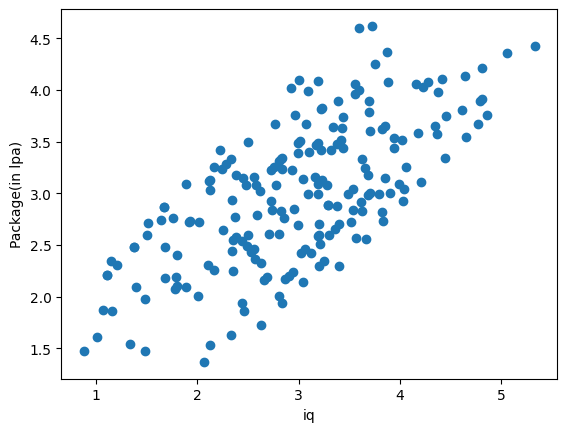

In [22]:
# create a scatter plot to visualize the relationship between IQ and package
plt.scatter(new_df2['iq'], new_df2['package'])

# label the x-axis as IQ
plt.xlabel('iq')

# label the y-axis as package in LPA
plt.ylabel('Package(in lpa)')

In [23]:
# select CGPA and IQ as input features
X = new_df2.iloc[:, 0:2]

# select package as the target variable
y = new_df2.iloc[:, -1]

# split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

# create a linear regression model
lr = LinearRegression()

# train the model using the training data
lr.fit(X_train, y_train)

# make predictions on the test data
y_pred = lr.predict(X_test)

In [24]:
# calculate the R-squared score for the model
print("R2 score: ", r2_score(y_test, y_pred))

# store the R-squared score in the variable r2
r2 = r2_score(y_test, y_pred)

R2 score:  0.8179423385767999


In [25]:
# calculate the adjusted R-squared value for the model with 2 input features
1 - ((1 - r2) * (40 - 1) / (40 - 1 - 2))

0.8081013839052755